In [242]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

# Parameters

In [243]:
# Dummy parameters:
dummyVMax = 1000
dummyKm = 0.0001
dummyEc50 = 0.0001
dummyK = 0.5

h2o = 10000 #DUMMY
proteinProductionVMax = dummyVMax
ribosomeKm = dummyKm

#NO3 to NO2
no3ReductionK = dummyK
no2OxidationK = dummyK
nrEc50 = dummyEc50

#NO2 to NO
no2ReductionK = dummyK
noOxidationK = dummyK
nirEc50 = dummyEc50

#NO to N2O
noReductionK = dummyK
n2oOxidationK = dummyK
norEc50 = dummyEc50

#N2O to N2
n2oReductionK = dummyK
n2OxidationK = dummyK
noszEc50 = dummyEc50

#Denitrification enzyme degradation
nrDegradationK = dummyK
nirDegradationK = dummyK
norDegradationK = dummyK
noszDegradationK = dummyK

#NR/NiR regulation
narxBindingK = dummyK
narxUnbindingK = dummyK
narxDegradationK = dummyK
narlPhosphorylationK = dummyK
narlpDephosphorylationK = dummyK
narlDegradationK = dummyK
narlpEc50 = dummyEc50


#NOR regulation
norrBindingK = dummyK
norrUnbindingK = dummyK
norrDegradationK = dummyK
norvwPhosphorylationK = dummyK
norvwpDephosphorylationK = dummyK
norvwDegradationK = dummyK
norvwpEc50 = dummyEc50

#NosZ regulation
nnrrBindingK = dummyK
nnrrUnbindingK = dummyK
nnrrDegradationK = dummyK
noNnrrEc50 = dummyEc50

# Nitrogen movement
nPumpVMax = dummyVMax
nPumpKm = dummyKm
n2DiffusionK = dummyK

# HPO4 to PO4
hpo4DehydrogenationK = dummyK
po4HydrogenationK = dummyK

#PO4 to Ca3PO4
precipitationK = dummyK

# Phosphorus movement
phosCellPumpVMax = dummyVMax
phosCellPumpKm = dummyKm
phosCompartmentPumpVMax = dummyVMax
phosCompartmentPumpKm = dummyKm

# Calcium movement
caExtracellular = 10000 #DUMMY
caDiffusionK = dummyK
caPumpVMax = dummyVMax
caCompartmentPumpKm = dummyKm

# Hydrogen movement
hDiffusionK = dummyK
hPumpVMax = dummyVMax
hPumpKm = dummyKm

# Transcription and mRNA degradation
transcriptionK = dummyK
mRNADegradationK = dummyK


# General Kinetic Equations

In [244]:
def hill(s, km):
    return s/(km+s)

# Rate Equations

## Denitrofication

In [245]:
def dNo3Extracellulardt(_no3Extracellular, _no3Cell):
    _no3Extracellular = max(0.0, _no3Extracellular) # Ensure nitrate concentration doesn't go negative
    return - nPumpVMax * hill(_no3Extracellular, nPumpKm)

def dNo3Celldt(_no3Extracellular, _no3Cell, _nr, _no2, _hCell, _narx, _no3Narx):
    return (nPumpVMax * hill(_no3Extracellular, nPumpKm)
            - no3ReductionK * hill(_nr, nrEc50) * _no3Cell * _hCell**2
            + no2OxidationK * hill(_nr, nrEc50) * _no2 * h2o
            - narxBindingK * _no3Cell * _narx
            + narxUnbindingK * _no3Narx)

def dNo2dt(_nr, _no3Cell, _hCell, _no2, _nir, _no):
    return (no3ReductionK * hill(_nr, nrEc50) * _no3Cell *_hCell**2
            - no2OxidationK * hill(_nr, nrEc50) * _no2 * h2o
            - no2ReductionK * hill(_nir, nirEc50) * _no2 * _hCell**2
            + noOxidationK * hill(_nir, nirEc50) * _no * h2o)

def dNodt(_nir, _no2, _hCell, _no, _nor, _n2o, _norr, _noNorr, _nnrr, _noNnrr):
    return (no2ReductionK * hill(_nir, nirEc50) * _no2 * _hCell**2
            - noOxidationK * hill(_nir, nirEc50) * _no * h2o
            - noReductionK * hill(_nor, norEc50) * _no * _hCell**2
            + n2oOxidationK * hill(_nor, norEc50) * _n2o * h2o
            - norrBindingK * _no * _norr
            + norrUnbindingK * _noNorr
            - nnrrBindingK * _no * _nnrr
            + nnrrUnbindingK * _noNnrr)

def dN2odt(_nor, _no, _hCell, _n2o, _nosz, _n2, _norr, _noNorr):
    return(noReductionK * hill(_nor, norEc50) * _no * _hCell**2
           - n2oOxidationK * hill(_nor, norEc50) * _n2o * h2o
           - n2oReductionK * hill(_nosz, noszEc50) * _n2o * _hCell**2
           + n2OxidationK * hill(_nosz, noszEc50) * _n2 * h2o)

def dN2dt(_nosz, _n2o, _hCell, _n2):
    return (n2oReductionK * hill(_nosz, noszEc50) * _n2o * _hCell**2
            - n2OxidationK * hill(_nosz, noszEc50) * _n2 * h2o
            - n2DiffusionK * _n2)

def dNarxdt(_mRNA, _narx, _no3Cell, _no3Narx):
    return (proteinProductionVMax * hill(_mRNA, ribosomeKm)
            - narxDegradationK * _narx
            - narxBindingK * _no3Cell * _narx
            + narxUnbindingK * _no3Narx)

def dNo3Narxdt(_no3Cell, _narx, _no3Narx):
    return (narxBindingK * _no3Cell * _narx
            - narxUnbindingK * _no3Narx)

def dNarLdt(_mRNA, _narl, _no3Narx, _narlp):
    return (proteinProductionVMax * hill(_mRNA, ribosomeKm)
            - narlDegradationK * _narl
            - narlPhosphorylationK * _no3Narx * _narl
            + narlpDephosphorylationK * _narlp)

def dNarlpdt(_narl, _no3Narx, _narlp):
    return (narlPhosphorylationK * _no3Narx * _narl
            - narlpDephosphorylationK * _narlp)

def dNorrdt(_mRNA, _norr, _no, _noNorr):
    return (proteinProductionVMax * hill(_mRNA, ribosomeKm)
            - norrDegradationK * _norr
            - norrBindingK * _no * _norr
            + norrUnbindingK * _noNorr)

def dNoNorrdt(_no, _norr, _noNorr):
    return (norrBindingK * _no * _norr
            - norrUnbindingK * _noNorr)

def dNorvwdt(_mRNA, _norvw, _noNorr, _norvwp):
    return (proteinProductionVMax * hill(_mRNA, ribosomeKm)
            - norvwDegradationK * _norvw
            - norvwPhosphorylationK * _noNorr * _norvw
            + norvwpDephosphorylationK * _norvwp)

def dNorvwpdt(_norvw, _noNorr, _norvwp):
    return (norvwPhosphorylationK * _noNorr * _norvw
            - norvwpDephosphorylationK * _norvwp)

def dNnrrdt(_mRNA, _nnrr, _no, _noNnrr):
    return (proteinProductionVMax * hill(_mRNA, ribosomeKm)
            - nnrrDegradationK * _nnrr
            - nnrrBindingK * _no * _nnrr
            + nnrrUnbindingK * _noNnrr)

def dNoNnrrdt(_no, _nnrr, _noNnrr):
    return (nnrrBindingK * _no * _nnrr
            - nnrrUnbindingK * _noNnrr)

def dDenitroEnzymedt(_denitromRNA, _denitroEnzyme, denitroEnzymeDegradationK):
    return (proteinProductionVMax * hill(_denitromRNA, ribosomeKm)
            - denitroEnzymeDegradationK * _denitroEnzyme)

#HCell/dt (in these steps) -> in/out of cell, plus/minus all reduction steps

#NR manages no3 to no2, narx binds to no3 to phosphorylate narL which transcribes NR
#NiR manages no2 to no, same regulation
#NOR manages no to n2o, norR binds to no to phosphorylate norVW which transcribes NOR
#NosZ manages n2o to n2, no binds to NnrR which transcribes NosZ


## Phosphorus Precipitation

In [246]:
def dHpo4Extracellulardt(_hpo4Extracellular):
    return -phosCellPumpVMax * hill(_hpo4Extracellular, phosCellPumpKm)

def dHpo4Celldt(_hpo4Extracellular, _hpo4Cell):
    _hpo4Cell = max(0.0, _hpo4Cell) # Ensure phosphate concentration in cell doesn't go negative
    return (phosCellPumpVMax * hill(_hpo4Extracellular, phosCellPumpKm)
            - phosCompartmentPumpVMax * hill(_hpo4Cell, phosCompartmentPumpKm))

def dHpo4Compartmentdt(_hpo4Cell, _hpo4Compartment, _po4, _hCompartment):
    return (phosCompartmentPumpVMax * hill(_hpo4Cell, phosCompartmentPumpKm)
            - hpo4DehydrogenationK * _hpo4Compartment
            + po4HydrogenationK * _po4 * _hCompartment)

def dPo4dt(_hpo4Compartment, _po4, _hCompartment, _caCompartment):
    return (hpo4DehydrogenationK * _hpo4Compartment
            - po4HydrogenationK * _po4 * _hCompartment
            - precipitationK * _caCompartment**3 * _po4)

def dCaCelldt(_caExtracellular, _caCell):
    _caCell = max(0.0, _caCell) # Ensure calcium concentration doesn't go negative
    return (caDiffusionK * (_caExtracellular - _caCell)
            - caPumpVMax * hill(_caCell, caCompartmentPumpKm))

def dCaCompartmentdt(_caCell, _caCompartment, _po4):
    return (caPumpVMax * hill(_caCell, caCompartmentPumpKm)
            - 3 * precipitationK * _caCompartment**3 * _po4)

def dCa3po4dt(_caCompartment, _po4):
    return precipitationK * _caCompartment**3 * _po4


## Hydrogen

In [247]:
def dHExtracellulardt(_hExtracellular, _hCell):
    return -hDiffusionK * (_hExtracellular - _hCell)

def dHCelldt(_hExtracellular, _hCell, _hCompartment, _nr, _no3Cell, _nir, _no2, _nor, _no, _nosz, _n2o, _n2):
    return (hDiffusionK * (_hExtracellular - _hCell) 
            + hPumpVMax * hill(_hCompartment, hPumpKm)
            - 2 * no3ReductionK * hill(_nr, nrEc50) * _no3Cell * _hCell**2
            - 2 * no2ReductionK * hill(_nir, nirEc50) * _no2 * _hCell**2
            - 2 * noReductionK * hill(_nor, norEc50) * _no * _hCell**2
            - 2 * n2oReductionK * hill(_nosz, noszEc50) * _n2o * _hCell**2
            + 2 * no2OxidationK * hill(_nr, nrEc50) * _no2 * h2o
            + 2 * noOxidationK * hill(_nir, nirEc50) * _no * h2o
            + 2 * n2oOxidationK * hill(_nor, norEc50) * _n2o * h2o
            + 2 * n2OxidationK * hill(_nosz, noszEc50) * _n2 * h2o)

def dHCompartmentdt(_hCell, _hCompartment, _hpo4Compartment, _po4):
    return (- hPumpVMax * hill(_hCompartment, hPumpKm)
            + hpo4DehydrogenationK * _hpo4Compartment
            - po4HydrogenationK * _po4 * _hCompartment)


## mRNA

In [248]:
def dmRNAdt(_mRNA):
    return (transcriptionK
            - mRNADegradationK * _mRNA)

def dmRNAActivateddt(_mRNA, _activator, _activatorEc50):
    return (transcriptionK * hill(_activator, _activatorEc50)
            - mRNADegradationK * _mRNA)

# nr is activated by narL, nir is activated by narL, nor is activated by norVW, nosZ is activated by nnrr

## Total Rate Equation

In [249]:
def dYdt(_t, _y):
    no3Extracellular, no3Cell, no2, no, n2o, n2, nr, nir, nor, nosz, narx, no3Narx, narl, narlp, norr, noNorr, norvw, norvwp, nnrr, noNnrr, hpo4Extracellular, hpo4Cell, hpo4Compartment, po4, caCell, caCompartment, ca3po4, hExtracellular, hCell, hCompartment, mRNA, nrmRNA, nirmRNA, normRNA, noszmRNA = _y
    return [dNo3Extracellulardt(no3Extracellular, no3Cell),
            dNo3Celldt(no3Extracellular, no3Cell, nr, no2, hCell, narx, no3Narx),
            dNo2dt(nr, no3Cell, hCell, no2, nir, no),
            dNodt(nir, no2, hCell, no, nor, n2o, norr, noNorr, nnrr, noNnrr),
            dN2odt(nor, no, hCell, n2o, nosz, n2, norr, noNorr),
            dN2dt(nosz, n2o, hCell, n2),
            dDenitroEnzymedt(nrmRNA, nr, nrDegradationK),
            dDenitroEnzymedt(nirmRNA, nir, nirDegradationK),
            dDenitroEnzymedt(normRNA, nor, norDegradationK),
            dDenitroEnzymedt(noszmRNA, nosz, noszDegradationK),
            dNarxdt(mRNA, narx, no3Cell, no3Narx),
            dNo3Narxdt(no3Cell, narx, no3Narx),
            dNarLdt(mRNA, narl, no3Narx, narlp),
            dNarlpdt(narl, no3Narx, narlp),
            dNorrdt(mRNA, norr, no, noNorr),
            dNoNorrdt(no, norr, noNorr),
            dNorvwdt(mRNA, norvw, noNorr, norvwp),
            dNorvwpdt(norvw, noNorr, norvwp),
            dNnrrdt(mRNA, nnrr, no, noNnrr),
            dNoNnrrdt(no, nnrr, noNnrr),
            dHpo4Extracellulardt(hpo4Extracellular),
            dHpo4Celldt(hpo4Extracellular, hpo4Cell),
            dHpo4Compartmentdt(hpo4Cell, hpo4Compartment, po4, hCompartment),
            dPo4dt(hpo4Compartment, po4, hCompartment, caCompartment),
            dCaCelldt(caExtracellular, caCell),
            dCaCompartmentdt(caCell, caCompartment, po4),
            dCa3po4dt(caCompartment, po4),
            dHExtracellulardt(hExtracellular, hCell),
            dHCelldt(hExtracellular, hCell, hCompartment, nr, no3Cell, nir, no2, nor, no, nosz, n2o, n2),
            dHCompartmentdt(hCell, hCompartment, hpo4Compartment, po4),
            dmRNAdt(mRNA),
            dmRNAActivateddt(nrmRNA, narlp, narlpEc50),
            dmRNAActivateddt(nirmRNA, narlp, narlpEc50),
            dmRNAActivateddt(normRNA, norvwp, norvwpEc50),
            dmRNAActivateddt(noszmRNA, noNnrr, noNnrrEc50)]

# Initial Conditions

In [250]:
dummyConcentration = 10000

no3Extracellular = dummyConcentration
no3Cell = 0
no2 = 0
no = 0
n2o = 0
n2 = 0
nr = 0
nir = 0
nor = 0
nosz = 0
narx = 0
no3Narx = 0
narl = 0
narlp = 0
norr = 0
noNorr = 0
norvw = 0
norvwp = 0
nnrr = 0
noNnrr = 0
hpo4Extracellular = dummyConcentration
hpo4Cell = 0
hpo4Compartment = 0
po4 = 0
caCell = 0
caCompartment = 0
ca3po4 = 0
hExtracellular = dummyConcentration
hCell = dummyConcentration
hCompartment = dummyConcentration
mRNA = 0
nrmRNA = 0
nirmRNA = 0
normRNA = 0
noszmRNA = 0

# Simulation

In [251]:
t0, tf = 0.0, 120.0 # time span for 5 days in hours

doseInterval = 12 # hours between doses

y = [no3Extracellular, no3Cell, no2, no, n2o, n2, nr, nir, nor, nosz, narx, no3Narx, narl, narlp, norr, noNorr, norvw, norvwp, nnrr, noNnrr,
     hpo4Extracellular, hpo4Cell, hpo4Compartment, po4, caCell, caCompartment, ca3po4,
     hExtracellular, hCell, hCompartment,
     mRNA, nrmRNA, nirmRNA, normRNA, noszmRNA]

T = np.arange(t0, tf, 1/60, dtype = float) # time points for ODE solver (every minute)
sol = scipy.integrate.solve_ivp(dYdt, (t0, tf), y, method='Radau', t_eval = T) # initial ODE solution for the entire time span (every minute)
Y = sol.y.T # variable values from the solution

Y = np.array(Y) # convert list to array
T = np.array(T) # convert list to array

no3Extracellular = Y[:, 0]
no3Cell = Y[:, 1]
no2 = Y[:, 2]
no = Y[:, 3]
n2o = Y[:, 4]
n2 = Y[:, 5]
nr = Y[:, 6]
nir = Y[:, 7]
nor = Y[:, 8]
nosz = Y[:, 9]
narx = Y[:, 10]
no3Narx = Y[:, 11]
narl = Y[:, 12]
narlp = Y[:, 13]
norr = Y[:, 14]
noNorr = Y[:, 15]
norvw = Y[:, 16]
norvwp = Y[:, 17]
nnrr = Y[:, 18]
noNnrr = Y[:, 19]
hpo4Extracellular = Y[:, 20]
hpo4Cell = Y[:, 21]
hpo4Compartment = Y[:, 22]
po4 = Y[:, 23]
caCell = Y[:, 24]
caCompartment = Y[:, 25]
ca3po4 = Y[:, 26]
hExtracellular = Y[:, 27]
hCell = Y[:, 28]
hCompartment = Y[:, 29]
mRNA = Y[:, 30]
nrmRNA = Y[:, 31]
nirmRNA = Y[:, 32]
normRNA = Y[:, 33]
noszmRNA = Y[:, 34]

t = T

# Plotting

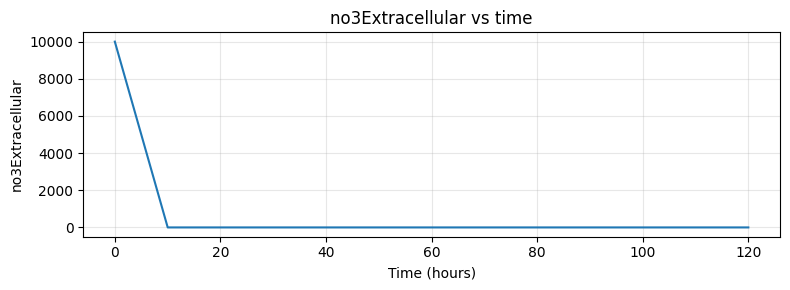

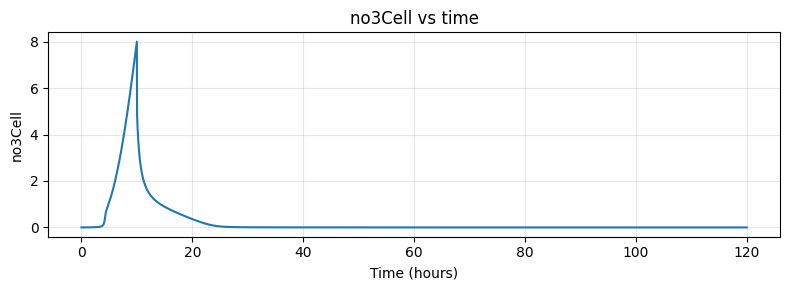

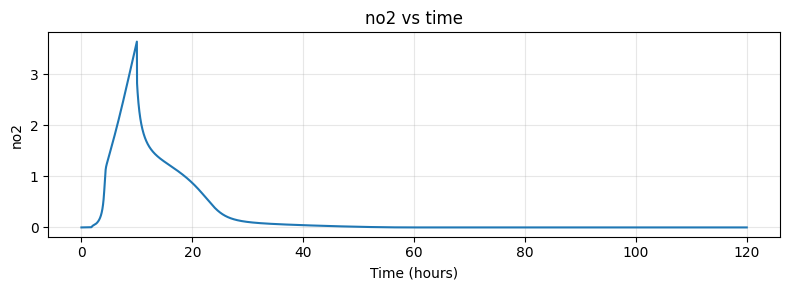

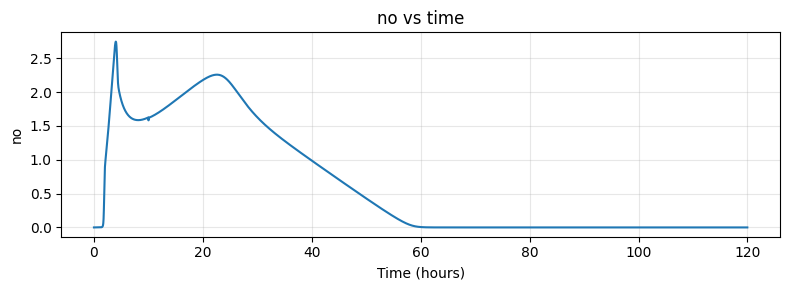

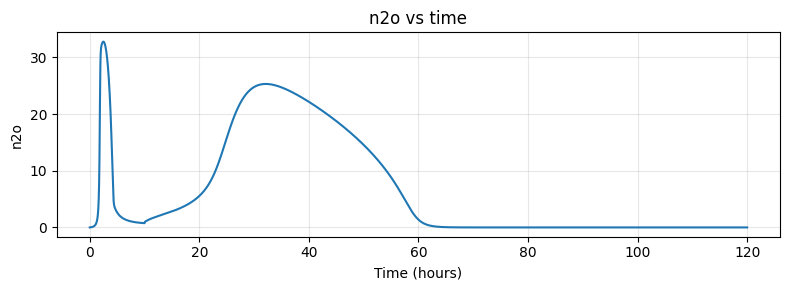

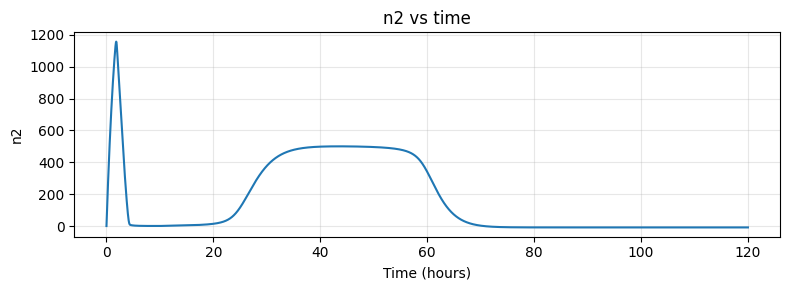

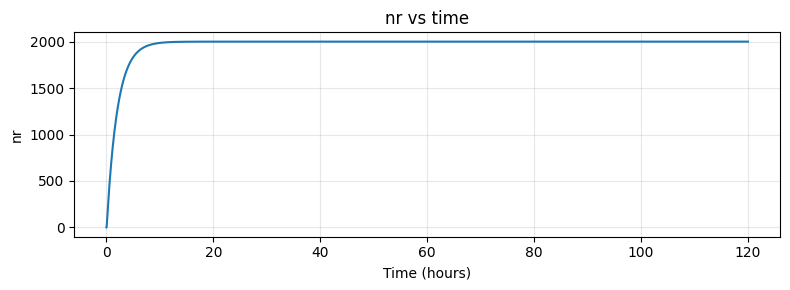

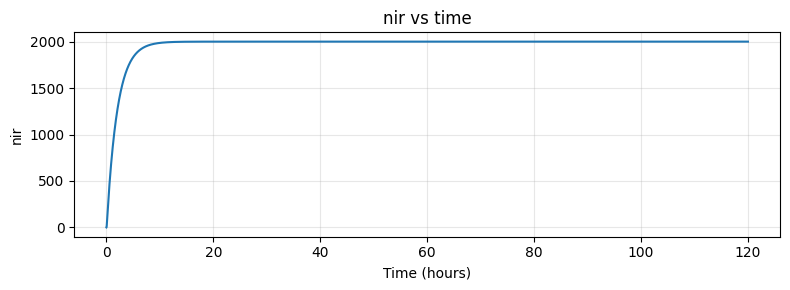

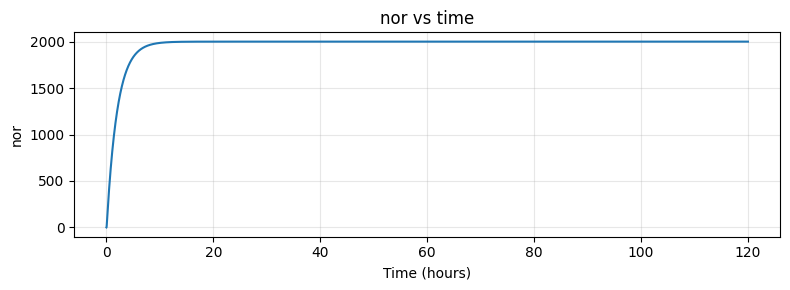

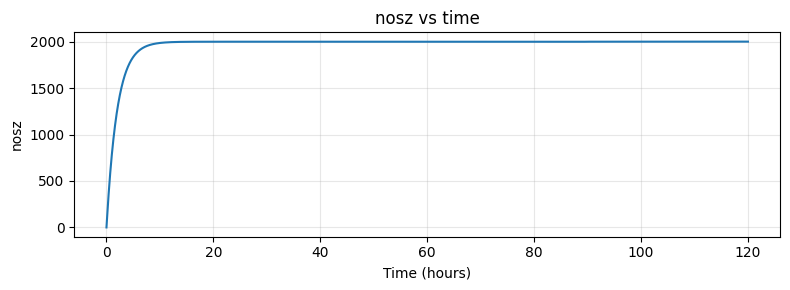

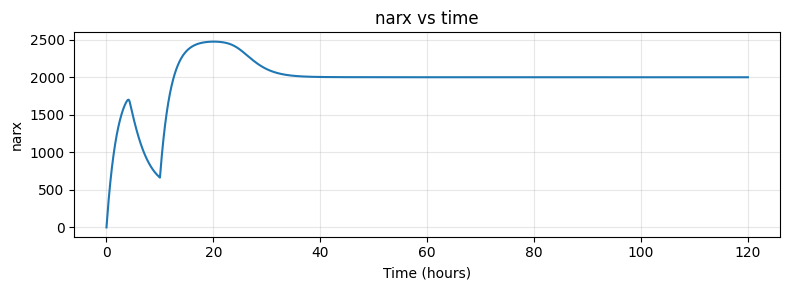

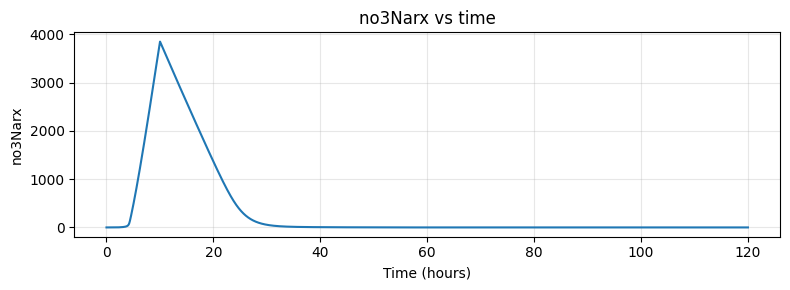

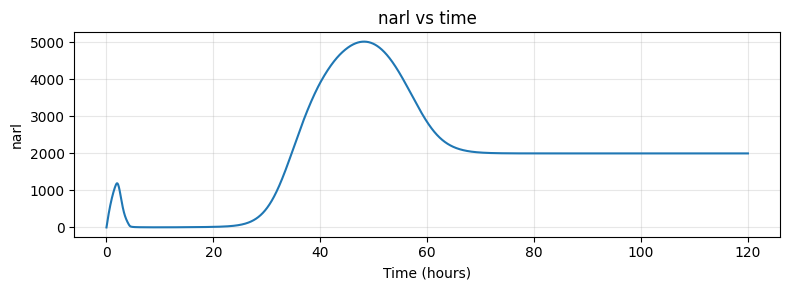

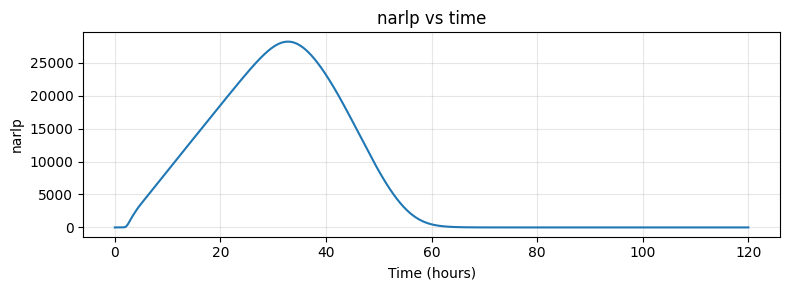

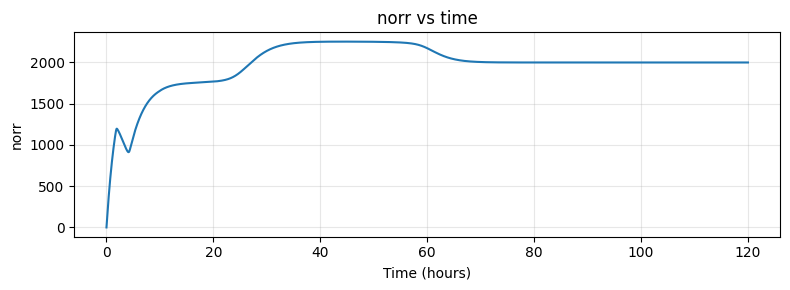

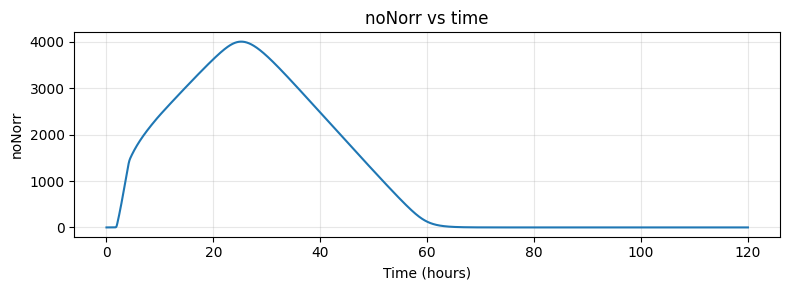

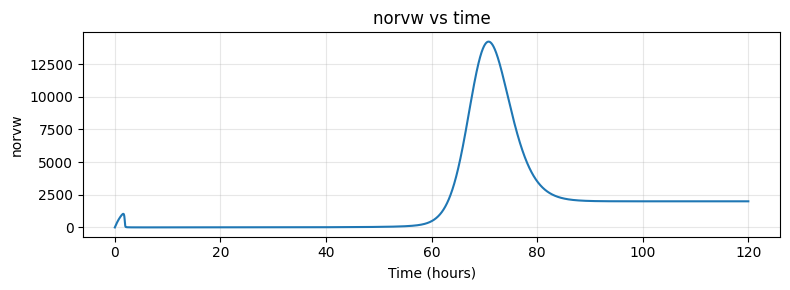

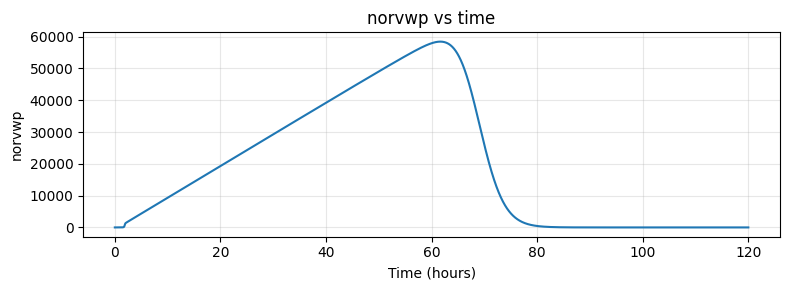

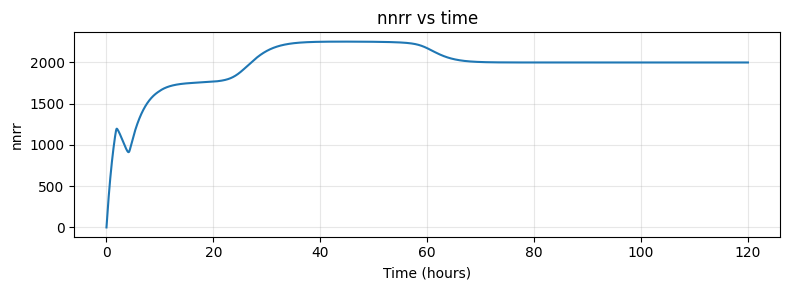

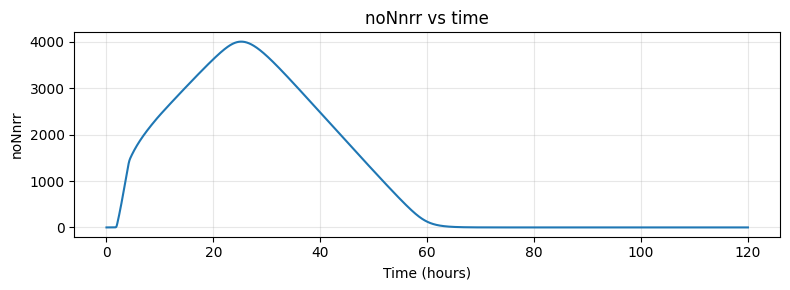

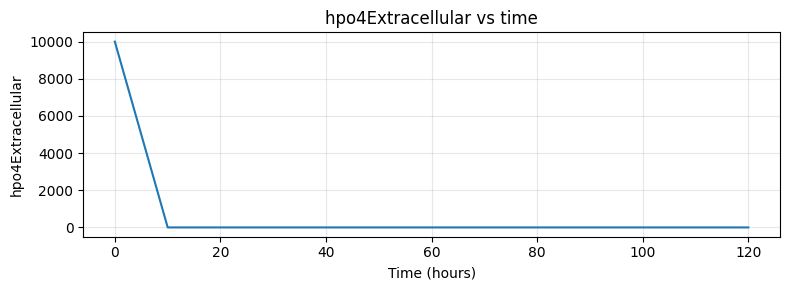

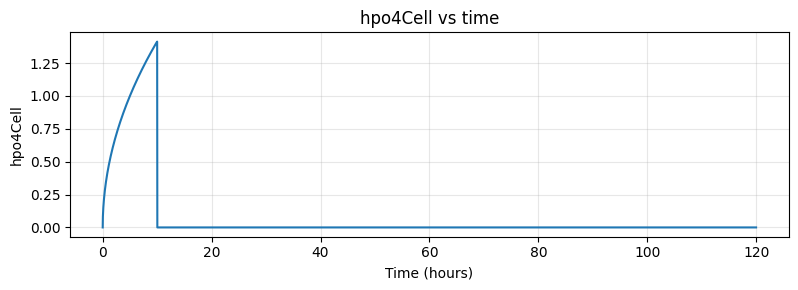

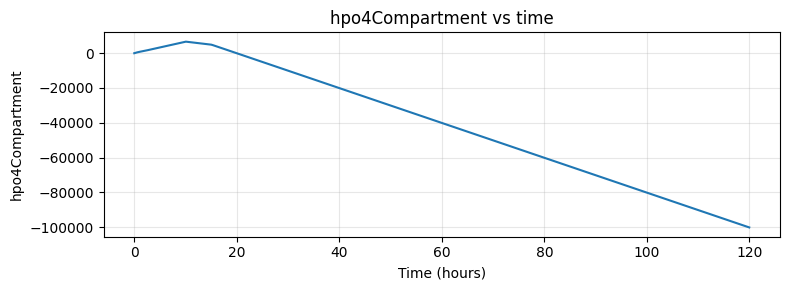

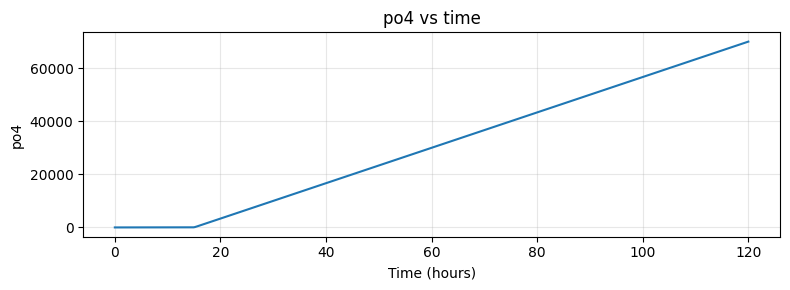

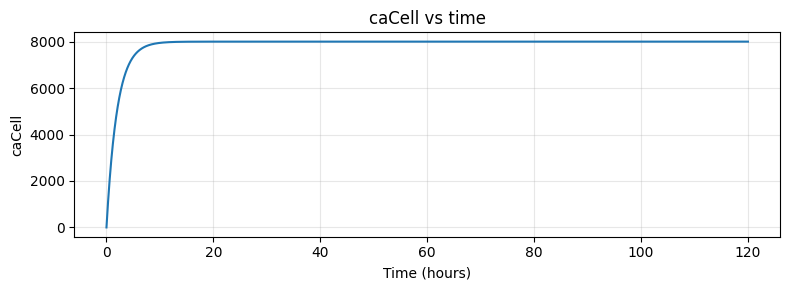

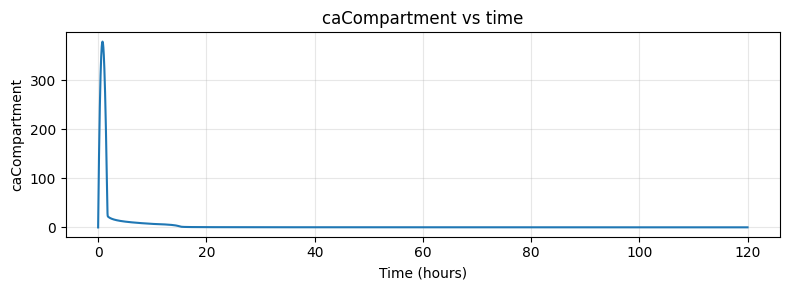

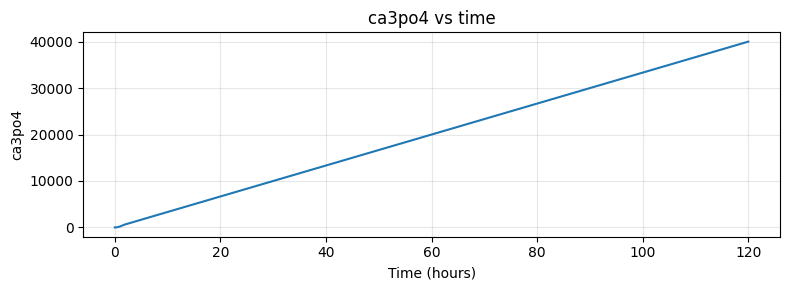

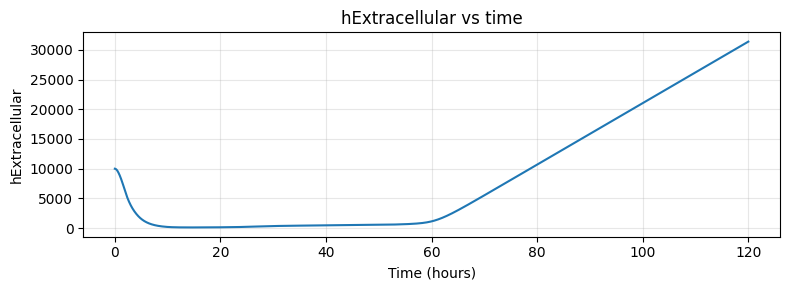

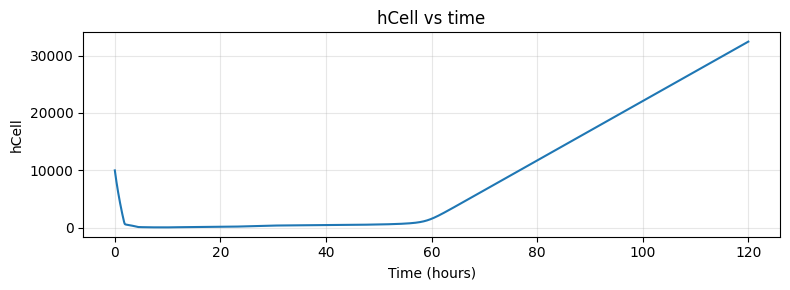

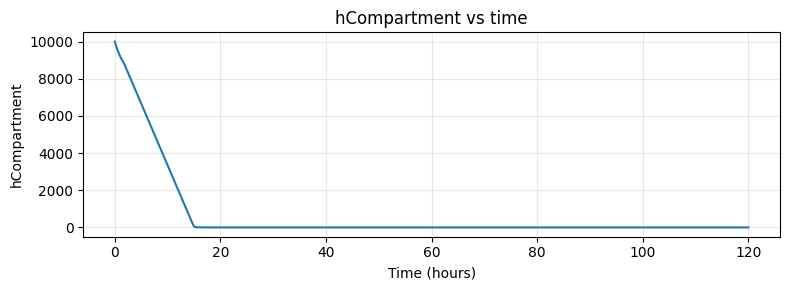

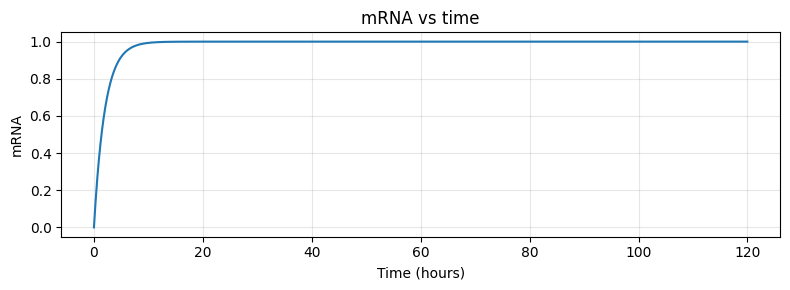

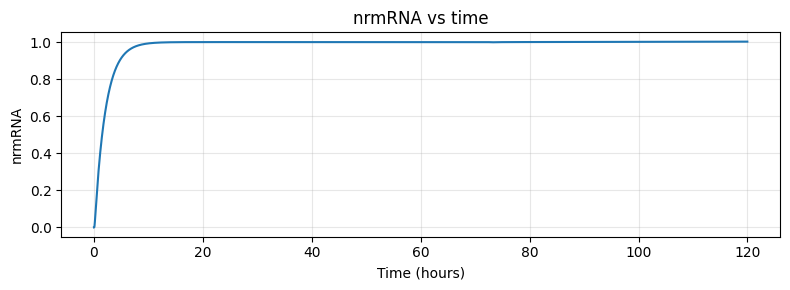

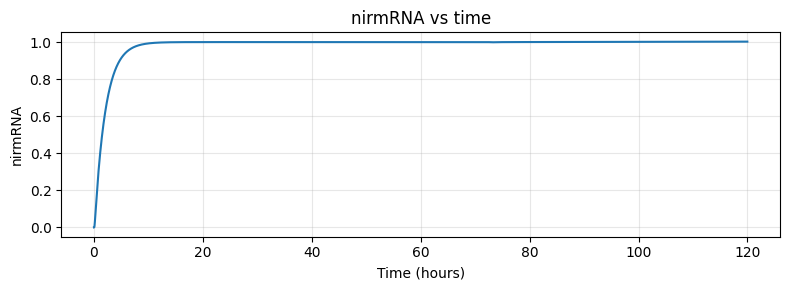

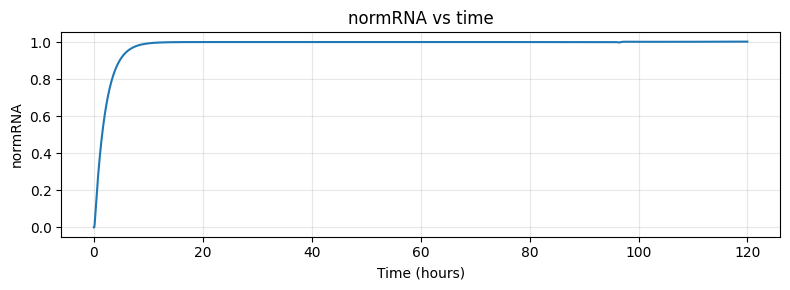

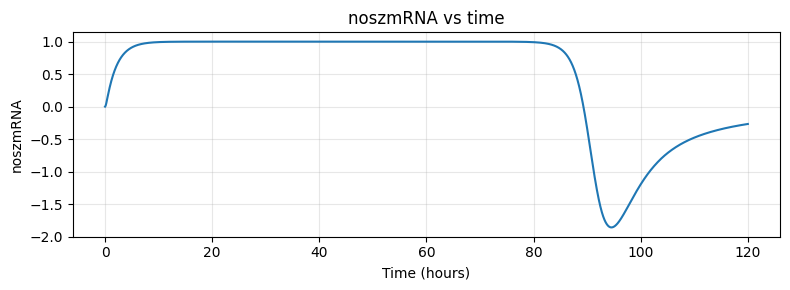

In [252]:
# Plot each state variable versus time
state_variables = [
    ("no3Extracellular", no3Extracellular),
    ("no3Cell", no3Cell),
    ("no2", no2),
    ("no", no),
    ("n2o", n2o),
    ("n2", n2),
    ("nr", nr),
    ("nir", nir),
    ("nor", nor),
    ("nosz", nosz),
    ("narx", narx),
    ("no3Narx", no3Narx),
    ("narl", narl),
    ("narlp", narlp),
    ("norr", norr),
    ("noNorr", noNorr),
    ("norvw", norvw),
    ("norvwp", norvwp),
    ("nnrr", nnrr),
    ("noNnrr", noNnrr),
    ("hpo4Extracellular", hpo4Extracellular),
    ("hpo4Cell", hpo4Cell),
    ("hpo4Compartment", hpo4Compartment),
    ("po4", po4),
    ("caCell", caCell),
    ("caCompartment", caCompartment),
    ("ca3po4", ca3po4),
    ("hExtracellular", hExtracellular),
    ("hCell", hCell),
    ("hCompartment", hCompartment),
    ("mRNA", mRNA),
    ("nrmRNA", nrmRNA),
    ("nirmRNA", nirmRNA),
    ("normRNA", normRNA),
    ("noszmRNA", noszmRNA),
]
for name, values in state_variables:
    plt.figure(figsize=(8, 3))
    plt.plot(t, values)
    plt.title(f"{name} vs time")
    plt.xlabel("Time (hours)")
    plt.ylabel(name)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
